$$
\begin{aligned}
& \text{\textbf{Sets \& Parameters:}} \\
& N \quad \text{(All nodes: depot } \cup \text{ customers } \cup \text{ stations)} \\
& C \subset N \quad \text{(Customers)}, \quad S \subset N \quad \text{(Charging stations)}, \quad 0 \in N \quad \text{(Depot)} \\
& K \quad \text{(Vehicles)}, \quad E \subseteq N \times N \quad \text{(Directed arcs)} \\
& d_{ij} \quad \text{(Length of arc } (i,j) \in E \text{)} \\
& q_i \quad \text{(Demand of customer } i \in C \text{)}, \quad Q \quad \text{(Vehicle load capacity)} \\
& B \quad \text{(Battery capacity)}, \quad \rho \quad \text{(Energy consumption rate)} \\ \\
& \text{\textbf{Decision Variables:}} \\
& x_{ijk} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ traverses arc } (i,j) \text{)} \\
& z_{ik} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ serves customer } i \text{)} \\
& y_k \in \{0,1\} \quad \text{(1 if vehicle } k \text{ is used)} \\
& g_{ik} \in [0, B] \quad \text{(SOC entering node } i \text{)} \\
& f_{ik} \in [0, B] \quad \text{(SOC leaving node } i \text{)} \\
& r_{ik} \in [0, B] \quad \text{(Charge added at station } i \in S \text{)} \\
& vs_{ik} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ visits station } i \in S \text{)} \\ \\
& \text{\textbf{Objective Function:}} \\
& \min \sum_{k \in K} \sum_{(i,j) \in E} d_{ij} \, x_{ijk} \\
& \text{\textbf{Constraints:}} \\
& \text{(1) Customer visit exactly once:} \quad \sum_{k \in K} z_{ik} = 1 \quad \forall i \in C \\
& \text{(2) Capacity:} \quad \sum_{i \in C} q_i z_{ik} \le Q \, y_k \quad \forall k \in K \\
& \text{(3) Charge gate:} \quad r_{ik} \le B \cdot vs_{ik} \quad \forall i \in S, \; \forall k \in K \\
& \text{(4) Battery — customer (no charging):} \quad f_{ik} = g_{ik} \quad \forall i \in C, \; \forall k \in K \\
& \text{(5) Battery — station (charging):} \quad f_{ik} = g_{ik} + r_{ik} \quad \forall i \in S, \; \forall k \in K \\
& \text{(6) Battery — depot (start full):} \quad f_{0k} = B \cdot y_k \quad \forall k \in K \\
& \text{(7) Battery drop on active arc:} \quad g_{jk} = f_{ik} - \rho \, d_{ij} \quad \text{if } x_{ijk} = 1 \\
& \text{(8) Routing — AddCircuit:} \quad \text{sl}_{ik} = \begin{cases} 1 - y_k & i = 0 \\ 1 - z_{ik} & i \in C \\ 1 - vs_{ik} & i \in S \end{cases} \\
& \text{(9) Bounds:} \quad 0 \le g_{ik}, f_{ik} \le B, \quad 0 \le r_{ik} \le B \\
& \qquad x_{ijk}, z_{ik}, y_k, vs_{ik} \in \{0,1\}
\end{aligned}
$$

> Making copies of a station — same coords, same neighbors, same roads —
lets each vehicle visit that station up to N times, where N = number of copies.

In [1]:
import math 
import random

In [2]:
random.seed(44)
depot = {0:(0,0)}
customers = { 
    1: (2, 4),
    2: (5, 1),
    3: (7, 5),
    4: (10, 2),
    5: (9, 8)}

# ---- stations ----
# 7 and 8 are COPIES of the same physical station at (8,3).
# Reason: AddCircuit allows each node to be visited at most once.
# By duplicating, station (8,3) can be visited up to 2 times.
stations = {6:(4,6),7:(8,3), 8:(8,3)}

nodes = depot|customers|stations


N = list(nodes.keys())
C = list(customers.keys())
S = list(stations.keys())

K = list(range(4))
D = list(depot.keys())[0] # == 0

Q = 10 #kg
B = 15 #kWh
rho = 0.8 #kWh/km
# max distance to travel : B/rho 
q = {i: random.randint(1,5) for i in C}

# ---- roads ----
# Copies MUST have identical neighbors.
# No arc between copies (same physical point).
roads = [
    (0, 1), (0, 2),
    (0, 6),
    (0, 3), (0, 4), (0, 5),
    (0, 7), (0, 8),
    (1, 6),
    (2, 6), (2, 7), (2, 8),
    (3, 6), (3, 7), (3, 8),
    (4, 7), (4, 8),
    (5, 3), (5, 7), (5, 8),
    (6, 7), (6, 8),
]
# directed arcs
E = []
for i,j in roads:
    E.append((i,j))
    E.append((j,i))
sum(q.values())

17

In [3]:
distance = {}
for i in (N):
    for j in (N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [4]:
SCALE = 100
B = B* SCALE
consumption = {
    (i,j) : round(rho*distance[i,j] * SCALE)
    for i,j in E
}

In [5]:
from ortools.sat.python import cp_model

In [6]:
model = cp_model.CpModel()

In [7]:
z = {(i,k): model.NewBoolVar(f"z[{i},{k}]") for i in C for k in K}
y = {k: model.NewBoolVar(f"y[{k}]")for k in K}

g = {(i,k) : model.NewIntVar(0,B,f"g[{i},{k}]") for i in N for k in K}
f = {(i,k) : model.NewIntVar(0,B,f"f[{i},{k}]") for i in N for k in K}

r = {(i,k) : model.NewIntVar(0,B, f"r[{i},{k}]") for i in S for k in K}
vs = {(i,k) : model.NewBoolVar(f"vs[{i},{k}]") for i in S for k in K}

In [8]:
x = {}
for k in K:
    arcs =[]
    # real arcs
    for (i,j) in E:
        # if i !=j:
        x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
        arcs.append((i,j,x[i,j,k]))
        
    #self loops 
    for i in N:
        if i == D: # Depot
            x[D,D,k] = y[k].Not()
        elif i in S:
            x[i,i,k] = vs[i,k].Not()
        else:
            x[i,i,k] = z[i,k].Not()
        arcs.append((i,i,x[i,i,k]))
    model.AddCircuit(arcs)
            

In [9]:
# each customer once
for i in C:
    model.Add(sum(z[i,k] for k in K) == 1)

# capacity 
for k in K:
    model.Add(sum(q[i]*z[i,k] for i in C) <= Q*y[k])

In [10]:
#charge gate
for i in S:
    for k in K:
        model.Add(r[i,k] <= B * vs[i,k])

In [11]:
# battery at customers (No Charging)!
for i in C:
    for k in K:
        model.Add(f[i,k] == g[i,k])

# at charging stations(reset/ charge)
for i in S:
    for k in K:
        model.Add(f[i,k] == g[i,k] + r[i,k])

# Depot(start full)
for k in K:
    model.Add(f[D,k] == B*y[k])

# Battery drop on arc:
for (i,j) in E:
    for k in K:
        model.Add(g[j,k] == f[i,k] - consumption[i,j]).OnlyEnforceIf([x[i,j,k]])

In [12]:
model.Minimize(
    sum(distance[i,j] * x[i,j,k]
        for i, j in E
        for k in K)
)

In [13]:
solver = cp_model.CpSolver()
status = solver.solve(model)
status

<CpSolverStatus.OPTIMAL: 4>

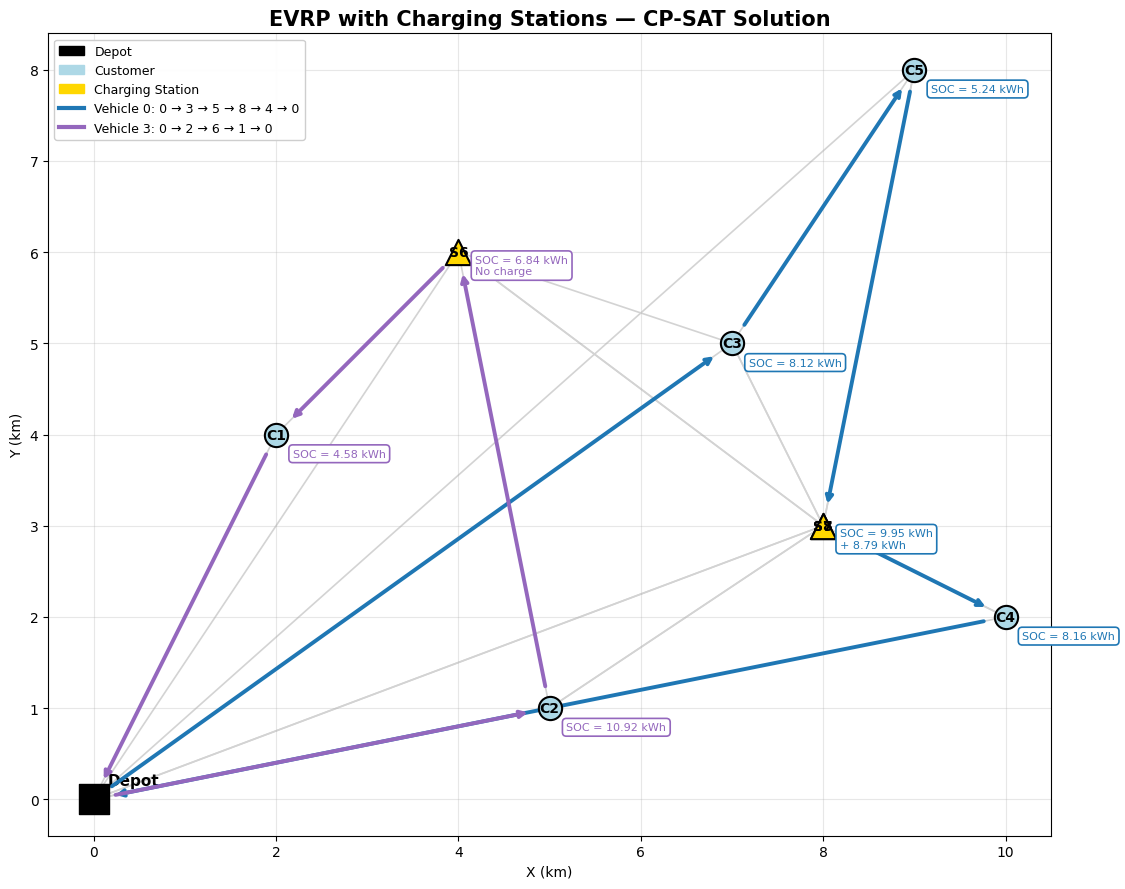

In [18]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize(solver, x, y, z, vs, g, f, r, nodes, C, S, K, E, D=0, SCALE=100):
    fig, ax = plt.subplots(figsize=(13, 9))

    # 1. Draw road network
    drawn_edges = set()
    for i, j in E:
        edge = tuple(sorted((i, j)))
        if edge in drawn_edges:
            continue
        drawn_edges.add(edge)
        xi, yi = nodes[i]
        xj, yj = nodes[j]
        ax.plot([xi, xj], [yi, yj], color='lightgray', lw=1.2, zorder=1)

    # 2. Nodes
    ax.scatter(*nodes[D], c='black', s=450, marker='s', zorder=5)
    ax.annotate('Depot', nodes[D], fontsize=11, fontweight='bold', xytext=(10, 10), textcoords='offset points')

    for i in C:
        ax.scatter(*nodes[i], c='lightblue', s=280, edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(f'C{i}', nodes[i], fontsize=10, fontweight='bold', ha='center', va='center', zorder=7)

    for i in S:
        ax.scatter(*nodes[i], c='gold', s=330, marker='^', edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(f'S{i}', nodes[i], fontsize=10, fontweight='bold', ha='center', va='center', zorder=7)

    # 3. Vehicle colors
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple', 'tab:orange', 'tab:brown', 'tab:pink', 'tab:cyan']

    # 4. Draw routes
    for k in K:
        if solver.Value(y[k]) == 0:
            continue
        color = colors[k % len(colors)]

        route = [D]
        cur = D
        while True:
            nxt = next((j for i, j in E if i == cur and solver.Value(x[i, j, k]) == 1), None)
            if nxt is None:
                break
            route.append(nxt)
            if nxt == D:
                break
            cur = nxt

        for a, b in zip(route[:-1], route[1:]):
            ax.annotate('', xy=nodes[b], xytext=nodes[a],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.8, shrinkA=16, shrinkB=16), zorder=3)

        for i in route[1:-1]:
            soc = solver.Value(f[i, k]) / SCALE
            if i in S:
                charge = solver.Value(r[i, k]) / SCALE
                label = f'SOC = {soc:.2f} kWh\n+ {charge:.2f} kWh' if charge > 0 else f'SOC = {soc:.2f} kWh\nNo charge'
            else:
                label = f'SOC = {soc:.2f} kWh'
            ax.annotate(label, nodes[i], fontsize=8, color=color, xytext=(12, -16), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=color, lw=1.2), zorder=8)

        route_str = ' → '.join(map(str, route))
        ax.plot([], [], color=color, lw=3, label=f'Vehicle {k}: {route_str}')

    # 5. Legend
    depot_patch = mpatches.Patch(color='black', label='Depot')
    customer_patch = mpatches.Patch(color='lightblue', label='Customer')
    station_patch = mpatches.Patch(color='gold', label='Charging Station')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=[depot_patch, customer_patch, station_patch] + handles, loc='upper left', fontsize=9, framealpha=0.95)

    # 6. Plot settings
    ax.set_title('EVRP with Charging Stations — CP-SAT Solution', fontsize=15, fontweight='bold')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

visualize(solver, x, y, z, vs, g, f, r, nodes, C, S, K, E, D=0, SCALE=SCALE)